<a href="https://colab.research.google.com/github/Prachisoni07/ml/blob/main/U%5E2Net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/NathanUA/U-2-Net.git
%cd U-2-Net

!mkdir -p saved_models/u2net saved_models/u2netp
!wget https://github.com/NathanUA/U-2-Net/releases/download/1.0/u2net.pth -P saved_models/u2net/

Cloning into 'U-2-Net'...
remote: Enumerating objects: 1077, done.
remote: Counting objects: 100% (422/422), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 1077 (delta 398), reused 380 (delta 380), pack-reused 655 (from 2)
Receiving objects: 100% (1077/1077), 66.95 MiB | 29.78 MiB/s, done.
Resolving deltas: 100% (536/536), done.
/content/U-2-Net
--2025-03-11 12:31:21--  https://github.com/NathanUA/U-2-Net/releases/download/1.0/u2net.pth
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/xuebinqin/U-2-Net/releases/download/1.0/u2net.pth [following]
--2025-03-11 12:31:21--  https://github.com/xuebinqin/U-2-Net/releases/download/1.0/u2net.pth
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 404 Not Found
2025-03-11 12:31:22 ERROR 404: Not Found.



In [2]:
!pip install torch torchvision opencv-python matplotlib scikit-image

In [4]:
!python u2net_test.py --model_name u2net

['/content/U-2-Net/test_data/test_images/hockey.png', '/content/U-2-Net/test_data/test_images/rifle2.jpeg', '/content/U-2-Net/test_data/test_images/im_01.png', '/content/U-2-Net/test_data/test_images/im_27.png', '/content/U-2-Net/test_data/test_images/horse.jpg', '/content/U-2-Net/test_data/test_images/sailboat3.jpg', '/content/U-2-Net/test_data/test_images/boat.jpg', '/content/U-2-Net/test_data/test_images/long.jpg', '/content/U-2-Net/test_data/test_images/0003.jpg', '/content/U-2-Net/test_data/test_images/rifle1.jpg', '/content/U-2-Net/test_data/test_images/bike.jpg', '/content/U-2-Net/test_data/test_images/girl.png', '/content/U-2-Net/test_data/test_images/0002-01.jpg', '/content/U-2-Net/test_data/test_images/im_21.png', '/content/U-2-Net/test_data/test_images/vangogh.jpeg', '/content/U-2-Net/test_data/test_images/lamp2_meitu_1.jpg', '/content/U-2-Net/test_data/test_images/im_14.png', '/content/U-2-Net/test_data/test_images/whisk.png']
...load U2NET---173.6 MB
/content/U-2-Net/u2net

mv: cannot stat '/content/maxwell.jpg': No such file or directory
Image path: maxwell.jpg
Does the image exist? True
['/content/U-2-Net/test_data/test_images/maxwell.ml2.jpg', '/content/U-2-Net/test_data/test_images/hockey.png', '/content/U-2-Net/test_data/test_images/rifle2.jpeg', '/content/U-2-Net/test_data/test_images/im_01.png', '/content/U-2-Net/test_data/test_images/im_27.png', '/content/U-2-Net/test_data/test_images/horse.jpg', '/content/U-2-Net/test_data/test_images/sailboat3.jpg', '/content/U-2-Net/test_data/test_images/boat.jpg', '/content/U-2-Net/test_data/test_images/long.jpg', '/content/U-2-Net/test_data/test_images/maxwell.jpg', '/content/U-2-Net/test_data/test_images/0003.jpg', '/content/U-2-Net/test_data/test_images/rifle1.jpg', '/content/U-2-Net/test_data/test_images/bike.jpg', '/content/U-2-Net/test_data/test_images/girl.png', '/content/U-2-Net/test_data/test_images/0002-01.jpg', '/content/U-2-Net/test_data/test_images/im_21.png', '/content/U-2-Net/test_data/test_imag

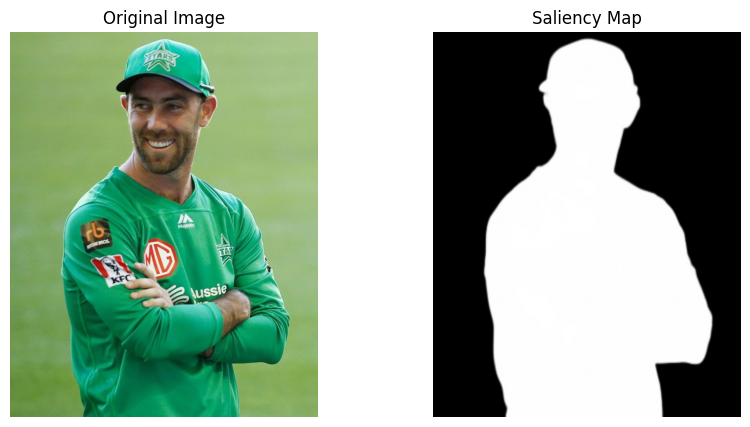

Mounted at /content/drive
Saliency map saved to: /content/drive/My Drive/maxwell_saliency.png


In [14]:
image_path = "/content/maxwell.jpg"
!mv "{image_path}" ./test_data/test_images/maxwell.jpg

image_path = "maxwell.jpg"

import os
print(f"Image path: {image_path}")
print(f"Does the image exist? {os.path.exists(f'./test_data/test_images/{image_path}')}")

!mkdir -p ./test_data/u2net_results

!python u2net_test.py --model_name u2net

result_path = f"./test_data/u2net_results/{image_path.split('.')[0]}.png"
print(f"Result path: {result_path}")
print(f"Does the output file exist? {os.path.exists(result_path)}")

import matplotlib.pyplot as plt
import cv2

original_image = cv2.imread(f"./test_data/test_images/{image_path}")
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

saliency_map = cv2.imread(result_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(original_image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Saliency Map')
plt.imshow(saliency_map, cmap='gray')
plt.axis('off')

plt.show()

from google.colab import drive

drive.mount('/content/drive')

output_path = f"/content/drive/My Drive/{image_path.split('.')[0]}_saliency.png"
cv2.imwrite(output_path, saliency_map)
print(f"Saliency map saved to: {output_path}")

In [15]:
import os
import zipfile
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split

In [16]:
import os
import zipfile

os.environ["KAGGLE_CONFIG_DIR"] = "/content"
!kaggle datasets download -d rajkumarl/people-clothing-segmentation

dataset_zip = "/content/U-2-Net/people-clothing-segmentation.zip"
extract_path = "/content/U-2-Net/train_data"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully.")

Dataset URL: https://www.kaggle.com/datasets/rajkumarl/people-clothing-segmentation
License(s): CC0-1.0
 96% 589M/616M [00:02<00:00, 284MB/s]
100% 616M/616M [00:02<00:00, 283MB/s]
✅ Dataset extracted successfully.


In [17]:
import shutil

os.makedirs("/content/U-2-Net/train_data/DUTS/DUTS-TR/DUTS-TR", exist_ok=True)

shutil.move("/content/U-2-Net/train_data/jpeg_images/IMAGES", "/content/U-2-Net/train_data/DUTS/DUTS-TR/DUTS-TR/im_aug")
shutil.move("/content/U-2-Net/train_data/jpeg_masks/MASKS", "/content/U-2-Net/train_data/DUTS/DUTS-TR/DUTS-TR/gt_aug")

print("✅ Dataset organized successfully.")

✅ Dataset organized successfully.


In [18]:
class ClothSegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.img_names = sorted(os.listdir(img_dir))
        self.mask_names = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_names[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_names[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return {'image': image, 'mask': mask}


In [19]:

from PIL import Image
import numpy as np
import torch

def RescaleT(image_size):

    def __call__(self, pil_img):
        w, h = pil_img.size
        if h > w:
            new_h, new_w = image_size, int(image_size * w / h)
        else:
            new_h, new_w = int(image_size * h / w), image_size
        new_pil_img = pil_img.resize((new_w, new_h), Image.BICUBIC)
        return new_pil_img

    return __call__


def RandomCrop(image_size):
    def __call__(self, pil_img):
        w, h = pil_img.size
        if h > w:
            new_h, new_w = image_size, int(image_size * w / h)
        else:
            new_h, new_w = int(image_size * h / w), image_size
        new_pil_img = pil_img.resize((new_w, new_h), Image.BICUBIC)

        x1 = 0
        y1 = 0
        if new_w > image_size:
            x1 = np.random.randint(0, new_w - image_size)
        if new_h > image_size:
            y1 = np.random.randint(0, new_h - image_size)
        cropped_pil_img = new_pil_img.crop((x1, y1, x1 + image_size, y1 + image_size))
        return cropped_pil_img

    return __call__


def ToTensorLab(flag=0):
    def __call__(self, pil_img):
        pil_img = pil_img.convert("RGB")
        tmp = np.array(pil_img)
        if flag == 1:
            tmp = np.array(to_lab(pil_img))
        tmp = tmp.transpose((2, 0, 1))
        tmp = tmp / 255.0
        tmp = torch.from_numpy(tmp)
        return tmp.type(torch.FloatTensor)

    return __call__

import skimage
from skimage import color

def to_lab(img):
    img_lab = color.rgb2lab(img)
    return img_lab

In [20]:
transform=transforms.Compose([
    RescaleT(512),
    RandomCrop(480),
    ToTensorLab(flag=0)
])

In [21]:
epoch_num = 200
batch_size_train = 8

In [22]:
!python u2net_train.py --model_name u2net

/usr/local/lib/python3.11/dist-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='mean' instead.
  warnings.warn(warning.format(ret))
---
train images:  0
train labels:  0
---
Traceback (most recent call last):
  File "/content/U-2-Net/u2net_train.py", line 94, in <module>
    salobj_dataloader = DataLoader(salobj_dataset, batch_size=batch_size_train, shuffle=True, num_workers=1)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 376, in __init__
    sampler = RandomSampler(dataset, generator=generator)  # type: ignore[arg-type]
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/sampler.py", line 164, in __init__
    raise ValueError(
ValueError: num_samples should be a positive integer value, but got num_

In [ ]:
!ls /content/U-2-Net/train_data

 DUTS   jpeg_images   jpeg_masks  'labels (1).csv'   labels.csv   png_images   png_masks


In [ ]:
!ls /content/U-2-Net/train_data/DUTS/DUTS-TR/DUTS-TR/im_aug
!ls /content/U-2-Net/train_data/DUTS/DUTS-TR/DUTS-TR/gt_aug


img_0001.jpeg  img_0168.jpeg  img_0335.jpeg  img_0502.jpeg  img_0669.jpeg  img_0836.jpeg
img_0002.jpeg  img_0169.jpeg  img_0336.jpeg  img_0503.jpeg  img_0670.jpeg  img_0837.jpeg
img_0003.jpeg  img_0170.jpeg  img_0337.jpeg  img_0504.jpeg  img_0671.jpeg  img_0838.jpeg
img_0004.jpeg  img_0171.jpeg  img_0338.jpeg  img_0505.jpeg  img_0672.jpeg  img_0839.jpeg
img_0005.jpeg  img_0172.jpeg  img_0339.jpeg  img_0506.jpeg  img_0673.jpeg  img_0840.jpeg
img_0006.jpeg  img_0173.jpeg  img_0340.jpeg  img_0507.jpeg  img_0674.jpeg  img_0841.jpeg
img_0007.jpeg  img_0174.jpeg  img_0341.jpeg  img_0508.jpeg  img_0675.jpeg  img_0842.jpeg
img_0008.jpeg  img_0175.jpeg  img_0342.jpeg  img_0509.jpeg  img_0676.jpeg  img_0843.jpeg
img_0009.jpeg  img_0176.jpeg  img_0343.jpeg  img_0510.jpeg  img_0677.jpeg  img_0844.jpeg
img_0010.jpeg  img_0177.jpeg  img_0344.jpeg  img_0511.jpeg  img_0678.jpeg  img_0845.jpeg
img_0011.jpeg  img_0178.jpeg  img_0345.jpeg  img_0512.jpeg  img_0679.jpeg  img_0846.jpeg
img_0012.jpeg  img_01

In [28]:
!git clone https://github.com/levindabhi/cloth-segmentation.git
%cd cloth-segmentation

Cloning into 'cloth-segmentation'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 62 (delta 5), reused 2 (delta 2), pack-reused 45 (from 1)
Receiving objects: 100% (62/62), 16.84 MiB | 40.67 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/U-2-Net/cloth-segmentation


In [29]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [30]:
import os
import zipfile

os.environ["KAGGLE_CONFIG_DIR"] = "/content"

!kaggle datasets download -d rajkumarl/people-clothing-segmentation

dataset_zip = "/content/cloth-segmentation/people-clothing-segmentation.zip"
extract_path = "/content/cloth-segmentation/train_data"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully.")

Dataset URL: https://www.kaggle.com/datasets/rajkumarl/people-clothing-segmentation
License(s): CC0-1.0
 99% 608M/616M [00:02<00:00, 240MB/s]
100% 616M/616M [00:02<00:00, 232MB/s]


FileNotFoundError: [Errno 2] No such file or directory: '/content/cloth-segmentation/people-clothing-segmentation.zip'

In [31]:
!python train.py --dataset_path /content/cloth-segmentation/train_data

2025-03-11 12:56:11.921054: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-11 12:56:11.942819: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-11 12:56:11.948981: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-11 12:56:13.037454: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
name training_cloth_segm_u2net_exp1
image_folder ../imaterialist/train/
df_path ../imaterialist/train.csv
distributed False
isTrain True
fine_width 768
fine_height 768
mean 0.5
std 0.5
batchSize 2
nThreads 2
max_dataset_size inf
serial_batch

In [32]:
!python train.py --dataset_path /content/cloth-segmentation/train_data --continue_train False

2025-03-11 12:56:22.267241: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-11 12:56:22.286454: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-11 12:56:22.292376: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-11 12:56:23.349869: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
name training_cloth_segm_u2net_exp1
image_folder ../imaterialist/train/
df_path ../imaterialist/train.csv
distributed False
isTrain True
fine_width 768
fine_height 768
mean 0.5
std 0.5
batchSize 2
nThreads 2
max_dataset_size inf
serial_batch

In [33]:
!python evaluate.py --dataset_path /content/cloth-segmentation/val_data

python3: can't open file '/content/U-2-Net/cloth-segmentation/evaluate.py': [Errno 2] No such file or directory


In [34]:
!python save_model.py --model_path /content/cloth-segmentation/models/trained_model.pth

python3: can't open file '/content/U-2-Net/cloth-segmentation/save_model.py': [Errno 2] No such file or directory


In [27]:
import os
import sys
import time
import yaml
import cv2
import pprint
import traceback
import numpy as np

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
import torch.distributed as dist
import torch.multiprocessing as mp
from torch.cuda.amp import autocast
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.tensorboard import SummaryWriter
from torchvision import models

from data.custom_dataset_data_loader import CustomDatasetDataLoader, sample_data

from options.base_options import parser
from utils.tensorboard_utils import board_add_images
from utils.saving_utils import save_checkpoints
from utils.saving_utils import load_checkpoint, load_checkpoint_mgpu
from utils.distributed import get_world_size, set_seed, synchronize, cleanup

from networks import U2NET


def options_printing_saving(opt):
    os.makedirs(opt.logs_dir, exist_ok=True)
    os.makedirs(opt.save_dir, exist_ok=True)
    os.makedirs(os.path.join(opt.save_dir, "images"), exist_ok=True)
    os.makedirs(os.path.join(opt.save_dir, "checkpoints"), exist_ok=True)

    option_dict = vars(opt)
    with open(os.path.join(opt.save_dir, "training_options.yml"), "w") as outfile:
        yaml.dump(option_dict, outfile)

    for key, value in option_dict.items():
        print(key, value)


def training_loop(opt):
    if opt.distributed:
        local_rank = int(os.environ.get("LOCAL_RANK"))
        device = torch.device(f"cuda:{local_rank}")
    else:
        device = torch.device("cuda:0")
        local_rank = 0

    u_net = U2NET(in_ch=3, out_ch=4)
    print("Model initialized from scratch.")

    u_net = u_net.to(device)
    u_net.train()

    if local_rank == 0:
        with open(os.path.join(opt.save_dir, "networks.txt"), "w") as outfile:
            print("<----U-2-Net---->", file=outfile)
            print(u_net, file=outfile)

    if opt.distributed:
        u_net = nn.parallel.DistributedDataParallel(
            u_net,
            device_ids=[local_rank],
            output_device=local_rank,
            broadcast_buffers=False,
        )
        print("Going super fast with DistributedDataParallel")

    optimizer = optim.Adam(
        u_net.parameters(), lr=0.001, betas=(0.9, 0.999), eps=1e-08, weight_decay=0
    )

    custom_dataloader = CustomDatasetDataLoader()
    custom_dataloader.initialize(opt)
    loader = custom_dataloader.get_loader()

    if local_rank == 0:
        dataset_size = len(custom_dataloader)
        print("Total number of images available for training: %d" % dataset_size)
        writer = SummaryWriter(opt.logs_dir)
        print("Entering training loop!")

    weights = np.array([1, 1.5, 1.5, 1.5], dtype=np.float32)
    weights = torch.from_numpy(weights).to(device)
    loss_CE = nn.CrossEntropyLoss(weight=weights).to(device)

    pbar = range(opt.iter)
    get_data = sample_data(loader)

    start_time = time.time()
    for itr in pbar:
        data_batch = next(get_data)
        image, label = data_batch
        image = Variable(image.to(device))
        label = label.type(torch.long)
        label = Variable(label.to(device))

        d0, d1, d2, d3, d4, d5, d6 = u_net(image)

        loss0 = loss_CE(d0, label)
        loss1 = loss_CE(d1, label)
        loss2 = loss_CE(d2, label)
        loss3 = loss_CE(d3, label)
        loss4 = loss_CE(d4, label)
        loss5 = loss_CE(d5, label)
        loss6 = loss_CE(d6, label)
        del d1, d2, d3, d4, d5, d6

        total_loss = loss0 * 1.5 + loss1 + loss2 + loss3 + loss4 + loss5 + loss6

        for param in u_net.parameters():
            param.grad = None

        total_loss.backward()
        if opt.clip_grad != 0:
            nn.utils.clip_grad_norm_(u_net.parameters(), opt.clip_grad)
        optimizer.step()

        if local_rank == 0:
            if itr % opt.print_freq == 0:
                pprint.pprint(
                    "[step-{:08d}] [time-{:.3f}] [total_loss-{:.6f}]  [loss0-{:.6f}]".format(
                        itr, time.time() - start_time, total_loss, loss0
                    )
                )

            if itr % opt.image_log_freq == 0:
                d0 = F.log_softmax(d0, dim=1)
                d0 = torch.max(d0, dim=1, keepdim=True)[1]
                visuals = [[image, torch.unsqueeze(label, dim=1) * 85, d0 * 85]]
                board_add_images(writer, "grid", visuals, itr)

            writer.add_scalar("total_loss", total_loss, itr)
            writer.add_scalar("loss0", loss0, itr)

            if itr % opt.save_freq == 0:
                save_checkpoints(opt, itr, u_net)

    print("Training done!")
    if local_rank == 0:
        itr += 1
        save_checkpoints(opt, itr, u_net)


if __name__ == "__main__":
    opt = parser()

    if opt.distributed:
        if int(os.environ.get("LOCAL_RANK")) == 0:
            options_printing_saving(opt)
    else:
        options_printing_saving(opt)

    try:
        if opt.distributed:
            print("Initialize Process Group...")
            torch.distributed.init_process_group(backend="nccl", init_method="env://")
            synchronize()

        set_seed(1000)
        training_loop(opt)
        cleanup(opt.distributed)
        print("Exiting..............")

    except KeyboardInterrupt:
        cleanup(opt.distributed)

    except Exception:
        traceback.print_exc(file=sys.stdout)
        cleanup(opt.distributed)

ModuleNotFoundError: No module named 'data'